# Import các thư viện

In [ ]:
import os
import cv2
import copy
import torch
import random
import numpy as np
from PIL import Image
from glob import glob
import torch.nn as nn
import torch.nn.functional
from torchvision import transforms
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Tạo đường dẫn

In [ ]:
ROOT_PATH = '/content/drive/MyDrive/Unet_Skin_Seg/Unet_Skin_Seg'
num_samples = 100  # or any smaller number you want
images_path = sorted(glob(os.path.join(ROOT_PATH, 'images', '*.jpg')))[:num_samples]
masks_path = sorted(glob(os.path.join(ROOT_PATH, 'masks', '*.png')))[:num_samples]

# Xây dựng các hàm để xử lí dữ liệu

Chuyển về ảnh xám

In [ ]:
img_size = (128, 128)

image_transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

def mask_transform(mask):
    mask = transforms.Resize(img_size, interpolation = Image.NEAREST)(mask)
    mask = transforms.functional.pil_to_tensor(mask).squeeze(0)
    mask = mask / 255.0
    mask = torch.round(mask).long()
    return mask


# Xây dựng các hàm tăng cường dữ liệu

elastic_transform (Biến dạng đàn hồi): Giúp mô hình nhận diện đặc trưng tốt hơn khi ảnh bị biến dạng

In [ ]:
def elastic_transform(image, mask, alpha_affine=10):
  random_state = np.random.RandomState(None)
  shape = image.size[::-1]

  center_square = np.float32(shape) // 2
  square_size = min(shape) // 3
  pts1 = np.float32([center_square + square_size,
                    [center_square[0] + square_size,
                     center_square[1] - square_size],
                     center_square - square_size])
  pts2 = pts1 + random_state.uniform(-alpha_affine, alpha_affine, size=pts1.shape).astype(np.float32)

  M = cv2.getAffineTransform(pts1, pts2)
  image = cv2.warpAffine(np.array(image), M, shape[::-1], borderMode=cv2.BORDER_REFLECT_101)
  mask = cv2.warpAffine(np.array(mask), M, shape[::-1], borderMode=cv2.BORDER_REFLECT_101)

  return Image.fromarray(image), Image.fromarray(mask)

horizontal_flip (Lật ngang): Lật image và mask theo chiều ngang, tăng khả năng nhận diện đối xứng

In [ ]:
def hflip_transform(image, mask):
  return image.transpose(Image.FLIP_LEFT_RIGHT), mask.transpose(Image.FLIP_LEFT_RIGHT)

vertical_flip (Lật dọc): Lật image và mask theo chiều dọc, bổ sung sự đa dạng giúp mô hình thích nghi với các góc nhìn khác nhau

In [ ]:
def vflip_transform(image, mask):
  return image.transpose(Image.FLIP_TOP_BOTTOM), mask.transpose(Image.FLIP_TOP_BOTTOM)

flip tổng hợp

In [ ]:
def flip_transform(image, mask):
  return image.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM), mask.transpose(Image.FLIP_LEFT_RIGHT).transpose(Image.FLIP_TOP_BOTTOM)

# Xây dựng PyTorch Dataset

In [ ]:
import os
class DatasetAugmented(Dataset):
  def __init__(self, images_path, masks_path, transform=None, target_transform=None, augmentations=None):
    # images_path and masks_path are now lists of files
    self.images_path = images_path
    self.masks_path = masks_path

    self.transform = transform
    self.target_transform = target_transform
    self.augmentations = augmentations if augmentations else []

    self.data = self._generate_augmented_data()

  def _generate_augmented_data(self):
    augmented_data = []
    for img_path, mask_path in zip(self.images_path, self.masks_path):
        # img_path and mask_path are already full paths

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        augmented_data.append((image, mask))

        for aug_func in self.augmentations:
            aug_image, aug_mask = aug_func(image, mask)
            augmented_data.append((aug_image, aug_mask))

    return augmented_data

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    image, mask = self.data[idx]

    if self.transform:
      image = self.transform(image)

    if self.target_transform:
      mask = self.target_transform(mask)

    return image, mask

In [ ]:
"""
class LazyAugmentedDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None, target_transform=None, augmentations=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform
        self.target_transform = target_transform
        self.augmentations = augmentations if augmentations else []

    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, idx):
        image = Image.open(self.images_path[idx]).convert('RGB')
        mask = Image.open(self.masks_path[idx]).convert('L')

        # Randomly apply one augmentation (or none)
        if self.augmentations:
            aug_func = random.choice([None] + self.augmentations)
            if aug_func:
                image, mask = aug_func(image, mask)

        if self.transform:
            image = self.transform(image)

        if self.target_transform:
            mask = self.target_transform(mask)

        return image, mask


# Khởi tạo dataset với augmentation

In [ ]:
augmentations = [elastic_transform, hflip_transform, vflip_transform]
dataset = DatasetAugmented(images_path, masks_path, transform=image_transform,
                                 target_transform=mask_transform, augmentations=augmentations)

# Phân chia dữ liệu

In [ ]:

from torch.utils.data import random_split

# Calculate split sizes
total_size = len(dataset)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 1 - train_ratio - val_ratio  # Ensure the ratios add up to 1

train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size  # Calculate test size directly

# Perform the split
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# Print split sizes for verification
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Total size: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Train size: 280
Validation size: 60
Test size: 60
Total size: 400


# Khai báo PyTorch DataLoader

In [ ]:
batch_size = 10

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Xây dựng Model

Khối Convolutional

In [ ]:
class ConvBlock(nn.Module):
  def __init__(self, in_channels, out_channels) -> None:
    super().__init__()
    self.conv_block = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True),

        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace = True)
    )

  def forward(self, x):
    x = self.conv_block(x)
    return x

Khối Encoder

In [ ]:
class Encoder(nn.Module):
  def __init__(self, in_channels, out_channels) -> None:
    super().__init__()
    self.encoder = nn.Sequential(
        ConvBlock(in_channels, out_channels),
        nn.MaxPool2d(2)
    )

  def forward(self, x):
    x = self.encoder(x)
    return x

Khối Decoder

In [ ]:
class Decoder(nn.Module):
  def __init__(self, in_channels, out_channels) -> None:
    super().__init__()
    self.conv_block = ConvBlock(in_channels, out_channels) # Create a ConvBlock instance
    self.conv_trans = nn.ConvTranspose2d(
        in_channels, # Pass in_channels directly
        out_channels, # Pass out_channels
        kernel_size=4,
        stride=2,
        padding = 1
    )

  def forward(self, x1, x2):
    x1 = self.conv_trans(x1)
    x = torch.cat([x2, x1], dim=1)
    x = self.conv_block(x) # Use the ConvBlock instance here
    return x

Model Unet

In [ ]:
class UNet(nn.Module):
  def __init__(self, num_classes, num_channels) -> None:
    super().__init__()
    self.num_classes = num_classes
    self.num_channels = num_channels

    self.in_conv = ConvBlock(num_channels, 64)

    self.encoder1 = Encoder(64, 128)
    self.encoder2 = Encoder(128, 256)
    self.encoder3 = Encoder(256, 512)
    self.encoder4 = Encoder(512, 1024)

    self.decoder1 = Decoder(1024, 512)
    self.decoder2 = Decoder(512, 256)
    self.decoder3 = Decoder(256, 128)
    self.decoder4 = Decoder(128, 64)

    self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

  def forward(self, x):
    x1 = self.in_conv(x)

    x2 = self.encoder1(x1)
    x3 = self.encoder2(x2)
    x4 = self.encoder3(x3)
    x5 = self.encoder4(x4)

    x = self.decoder1(x5, x4)
    x = self.decoder2(x, x3)
    x = self.decoder3(x, x2)
    x = self.decoder4(x, x1)

    x = self.out_conv(x)

    return x

Hàm Evaluate

In [ ]:
def evaluate(model, data_loader, criterion, device='cuda'):
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():  # Disable gradient calculation during evaluation
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()  # Accumulate the loss
    return total_loss / len(data_loader)  # Calculate average loss

# Khai báo tham số cho model

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet(num_channels=1, num_classes=2).to(device)
max_epoch = 10
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Model training và Evaluation

In [ ]:
# Training loop
for epoch in range(max_epoch):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += targets.size(0) * targets.size(1) * targets.size(2)
        correct_train += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    avg_train_loss = train_loss / len(train_loader)

    # Validation
    val_loss, val_acc = evaluate(model, val_loader, criterion, device) # Get both val_loss and val_acc
    # val_accuracy = 0 # Placeholder.  Implement validation accuracy calculation if needed.

    print(f"Epoch: {epoch+1}/{max_epoch}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.2f}") # Use val_acc

Epoch: 1/10, Train Loss: 0.1527, Train Accuracy: 93.88, Val Loss: 0.1821, Val Accuracy: 0.93
Epoch: 2/10, Train Loss: 0.1510, Train Accuracy: 93.95, Val Loss: 0.1792, Val Accuracy: 0.93
Epoch: 3/10, Train Loss: 0.1546, Train Accuracy: 93.73, Val Loss: 0.1802, Val Accuracy: 0.93
Epoch: 4/10, Train Loss: 0.1516, Train Accuracy: 93.93, Val Loss: 0.1787, Val Accuracy: 0.93
Epoch: 5/10, Train Loss: 0.1496, Train Accuracy: 93.96, Val Loss: 0.1791, Val Accuracy: 0.93
Epoch: 6/10, Train Loss: 0.1520, Train Accuracy: 93.89, Val Loss: 0.1821, Val Accuracy: 0.93
Epoch: 7/10, Train Loss: 0.1462, Train Accuracy: 94.11, Val Loss: 0.1796, Val Accuracy: 0.93
Epoch: 8/10, Train Loss: 0.1510, Train Accuracy: 93.94, Val Loss: 0.1826, Val Accuracy: 0.93
Epoch: 9/10, Train Loss: 0.1489, Train Accuracy: 94.02, Val Loss: 0.1820, Val Accuracy: 0.93
Epoch: 10/10, Train Loss: 0.1470, Train Accuracy: 94.07, Val Loss: 0.1828, Val Accuracy: 0.93


In [ ]:
best_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(max_epoch):
  model.train()
  train_loss = 0.0
  for inputs, targets in train_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_loss = train_loss / len(train_loader)

  val_loss = evaluate(model, val_loader, criterion, device=device)

  if val_loss < best_loss:
    best_loss = val_loss
    best_model_wts = copy.deepcopy(model.state_dict())

  print(f'Epoch: {epoch+1}/{max_epoch}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

model.load_state_dict(best_model_wts)

Epoch: 1/10, Train Loss: 0.4045, Val Loss: 0.2699
Epoch: 2/10, Train Loss: 0.2366, Val Loss: 0.2166
Epoch: 3/10, Train Loss: 0.1857, Val Loss: 0.1926
Epoch: 4/10, Train Loss: 0.1809, Val Loss: 0.2780
Epoch: 5/10, Train Loss: 0.1808, Val Loss: 0.3242
Epoch: 6/10, Train Loss: 0.1668, Val Loss: 0.1891
Epoch: 7/10, Train Loss: 0.1587, Val Loss: 0.1822
Epoch: 8/10, Train Loss: 0.1605, Val Loss: 0.2266
Epoch: 9/10, Train Loss: 0.1663, Val Loss: 0.1691
Epoch: 10/10, Train Loss: 0.1583, Val Loss: 0.1745


<All keys matched successfully>

# Summary Model

In [ ]:
!pip install torchsummary


In [ ]:
from torchsummary import summary
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(num_classes=2, num_channels=1).to(device)  # adjust if needed
summary(model, input_size=(1, 128, 128))  # (channels, height, width)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]             576
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
            Conv2d-4         [-1, 64, 128, 128]          36,864
       BatchNorm2d-5         [-1, 64, 128, 128]             128
              ReLU-6         [-1, 64, 128, 128]               0
         ConvBlock-7         [-1, 64, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]          73,728
       BatchNorm2d-9        [-1, 128, 128, 128]             256
             ReLU-10        [-1, 128, 128, 128]               0
           Conv2d-11        [-1, 128, 128, 128]         147,456
      BatchNorm2d-12        [-1, 128, 128, 128]             256
             ReLU-13        [-1, 128, 128, 128]               0
        ConvBlock-14        [-1, 128, 1

Lưu Model

In [ ]:
save_path = "/content/drive/MyDrive/Unet_Skin_Seg/Unet_Skin_Seg/model_Unet/UNet_model.pth"  # You can name it anything
torch.save(model.state_dict(), save_path)

# Xây dựng hàm hiển thị kết quả dự đoán

In [ ]:
def display_prediction(model, image, ground_truth, device):
  image = image.unsqueeze(0).to(device)
  with torch.no_grad():
    prediction = model(image)
    prediction = torch.argmax(prediction, dim=1).squeeze(0).cpu().numpy()

  image_np = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
  ground_truth_np = ground_truth.cpu().numpy()

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))
  axes[0].imshow(image_np, cmap='gray')
  axes[0].set_title('Input Image')
  axes[1].imshow(ground_truth_np, cmap='gray')
  axes[1].set_title('Ground Truth')
  axes[2].imshow(prediction, cmap='gray')
  axes[2].set_title('Prediction')
  for ax in axes:
    ax.axis('off')
  plt.show()

# Load trọng số và dự đoán

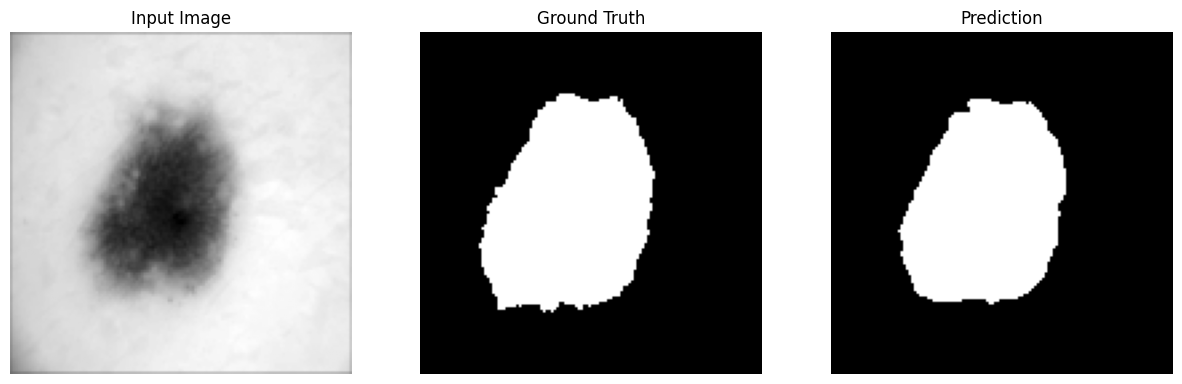

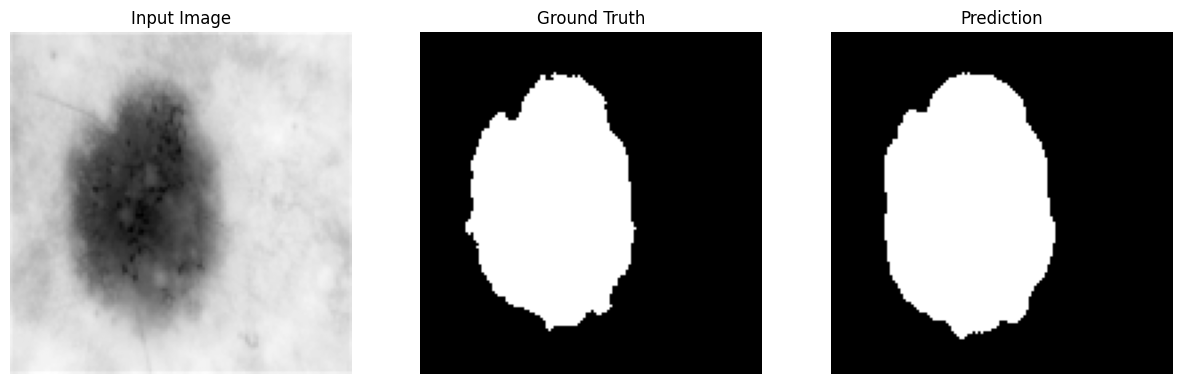

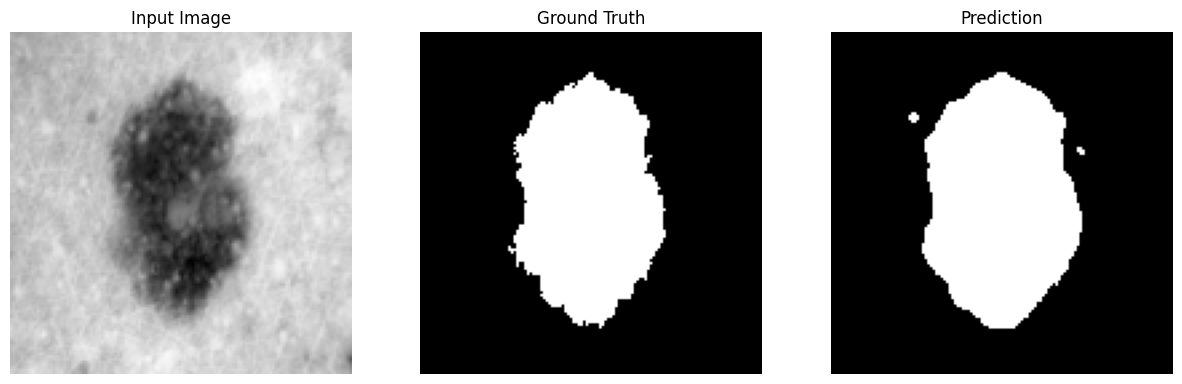

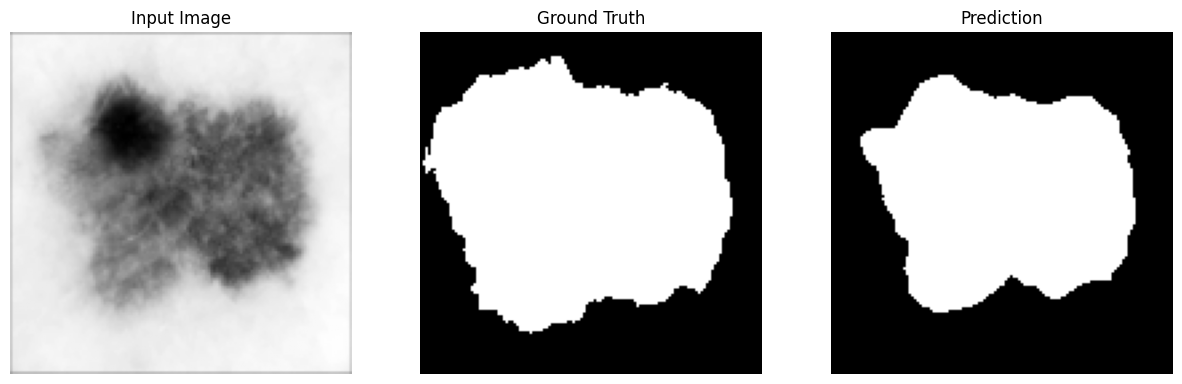

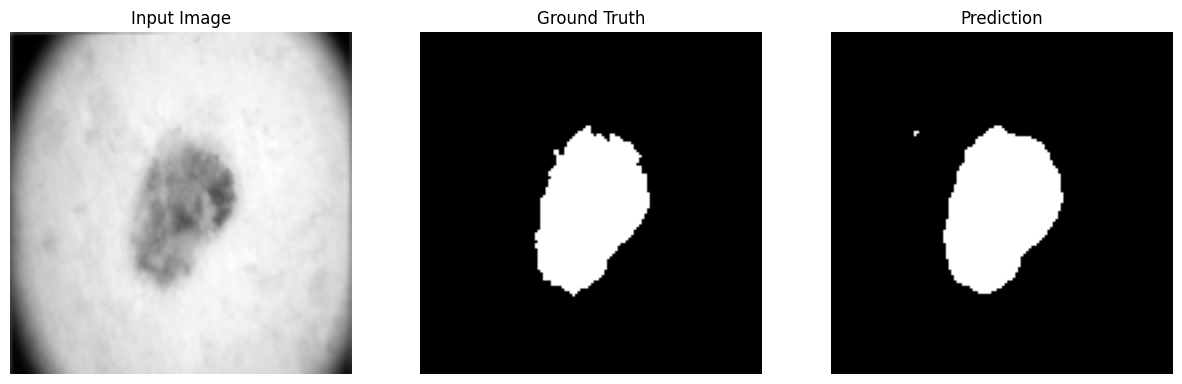

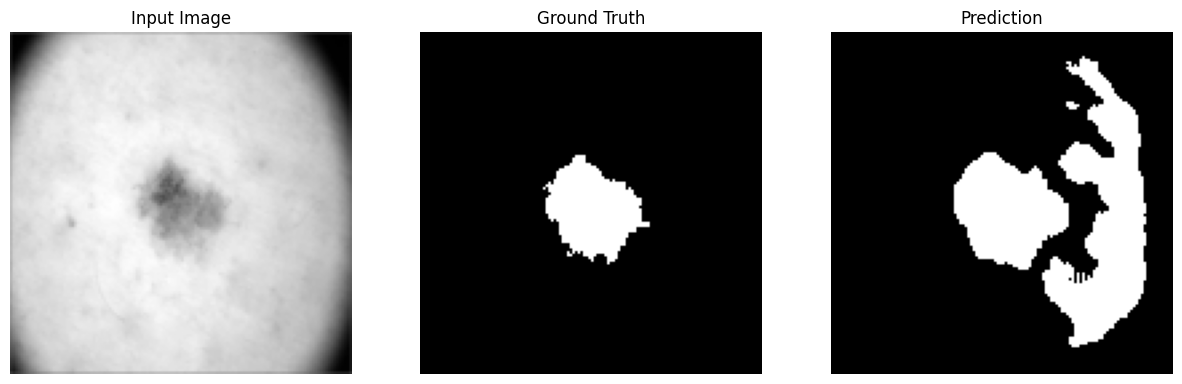

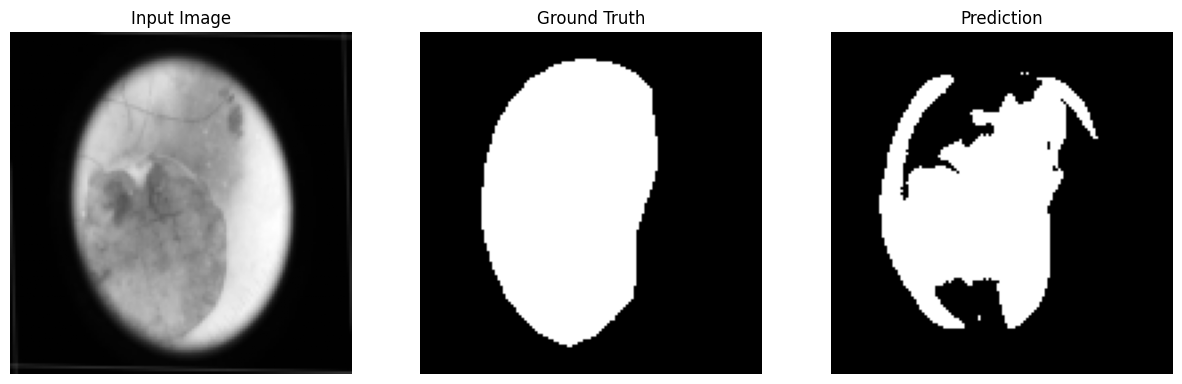

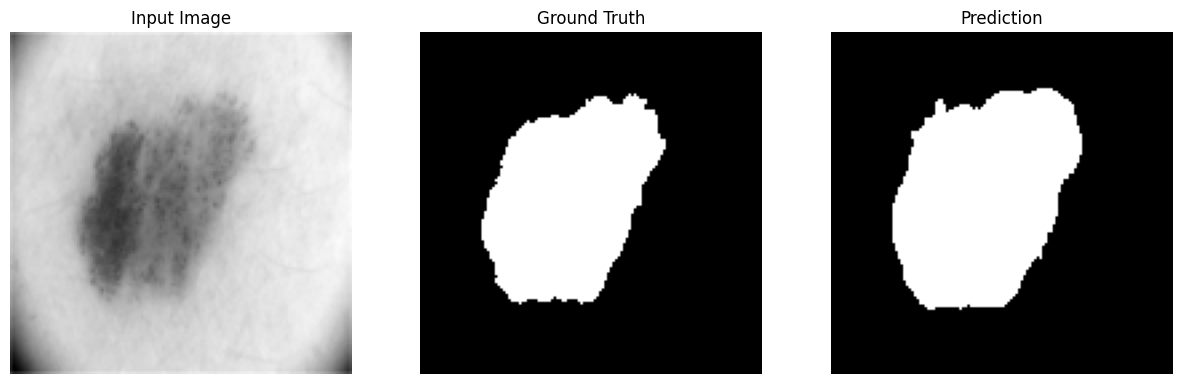

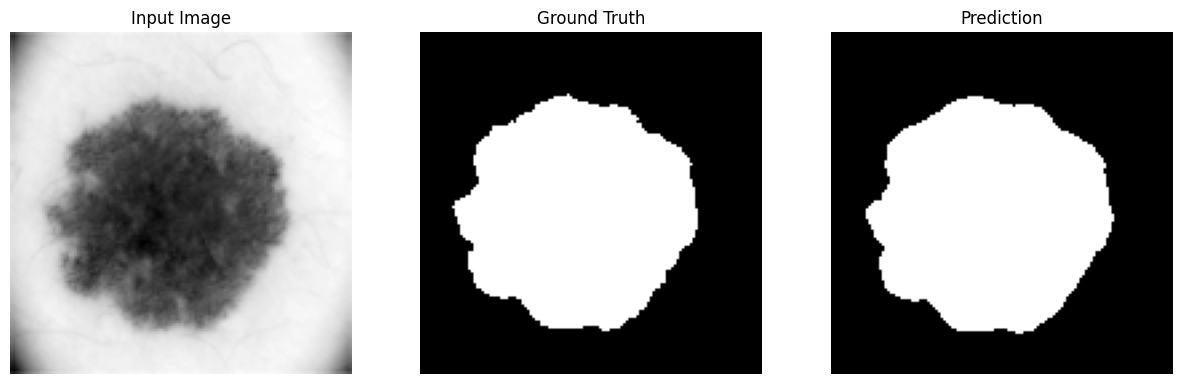

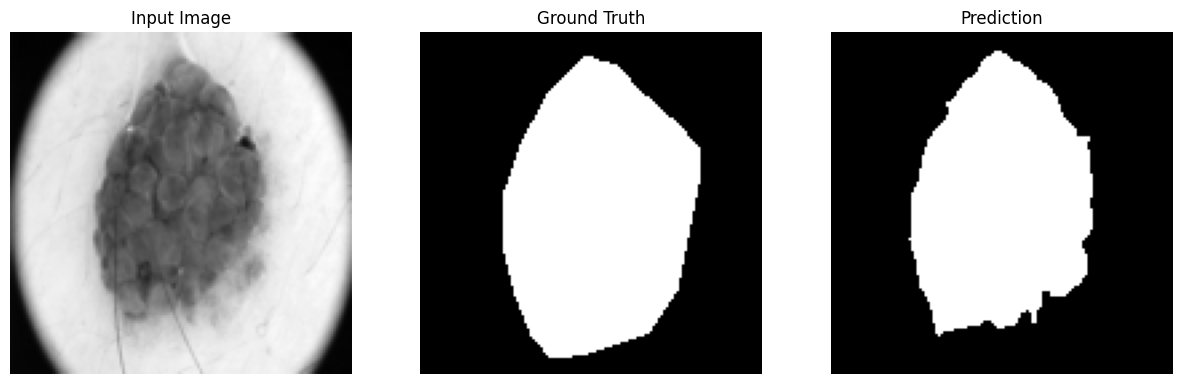

In [ ]:
model.load_state_dict(best_model_wts)

n_test_points = 10
model.eval()

test_sample = [test_dataset[i] for i in range(n_test_points)]

for i in range(n_test_points):
  img, gt = test_sample[i]
  display_prediction(model, img, gt, device)

***Nháp***

In [ ]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)  # Get predicted class per pixel
    correct = (preds == targets).float()
    acc = correct.sum() / correct.numel()
    return acc.item()

def evaluate(model, data_loader, criterion, device='cuda'):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_batches = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            # Accuracy
            acc = compute_accuracy(outputs, targets)
            total_acc += acc
            total_batches += 1

    avg_loss = total_loss / total_batches
    avg_acc = total_acc / total_batches
    return avg_loss, avg_acc


In [ ]:
val_loss, val_acc = evaluate(model, val_loader, criterion, device='cuda')
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


Validation Loss: 0.1691
Validation Accuracy: 93.33%
